# Cross-Cultural Movie Recommender: Model Analysis

**Korean Movie Recommender** — Content-based recommendation system that maps US movies to relevant Korean films using text embeddings, genre overlap, keyword matching, and cast/crew features.

This notebook presents evaluation results across three model architectures and analyzes feature importance, per-genre performance, and embedding space structure.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})
sns.set_theme(style="whitegrid", palette="muted")

# Color palette — consistent across all plots
COLORS = {"TF-IDF": "#5B9BD5", "Embedding": "#ED7D31", "Hybrid": "#70AD47"}
MODEL_NAMES = ["TF-IDF", "Embedding", "Hybrid"]

RESULTS = Path("../results")
DATA = Path("../data")
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


## Load Evaluation Results

In [2]:
# Load metrics for all three models
metrics = {}
for tag, label in [("tfidf", "TF-IDF"), ("embedding", "Embedding"), ("hybrid", "Hybrid")]:
    with open(RESULTS / f"metrics_v2_{tag}.json") as f:
        metrics[label] = json.load(f)

# Load tuning results
with open(RESULTS / "tune_results.json") as f:
    tune = json.load(f)

# Load data catalogs
us_movies = pd.read_csv(DATA / "processed" / "us_movies.csv")
kr_movies = pd.read_csv(DATA / "processed" / "kr_movies.csv")
gold_pairs = pd.read_csv(DATA / "eval" / "gold_pairs.csv")

print(f"Models loaded: {list(metrics.keys())}")
print(f"US catalog: {len(us_movies):,} movies | KR catalog: {len(kr_movies):,} movies")
print(f"Gold pairs: {len(gold_pairs)} ({gold_pairs['relevance'].value_counts().to_dict()})")
print(f"Best weights: { {k: round(v, 3) for k, v in tune['best_weights'].items()} }")

Models loaded: ['TF-IDF', 'Embedding', 'Hybrid']
US catalog: 5,000 movies | KR catalog: 1,512 movies
Gold pairs: 174 ({1: 157, 2: 14, 3: 3})
Best weights: {'text': 0.471, 'genre': 0.235, 'keyword': 0.176, 'cast': 0.0, 'year': 0.118}


## 1. Model Performance Comparison

Comparing three architectures on the primary retrieval metrics. Error bars show standard error across 56 evaluation queries.

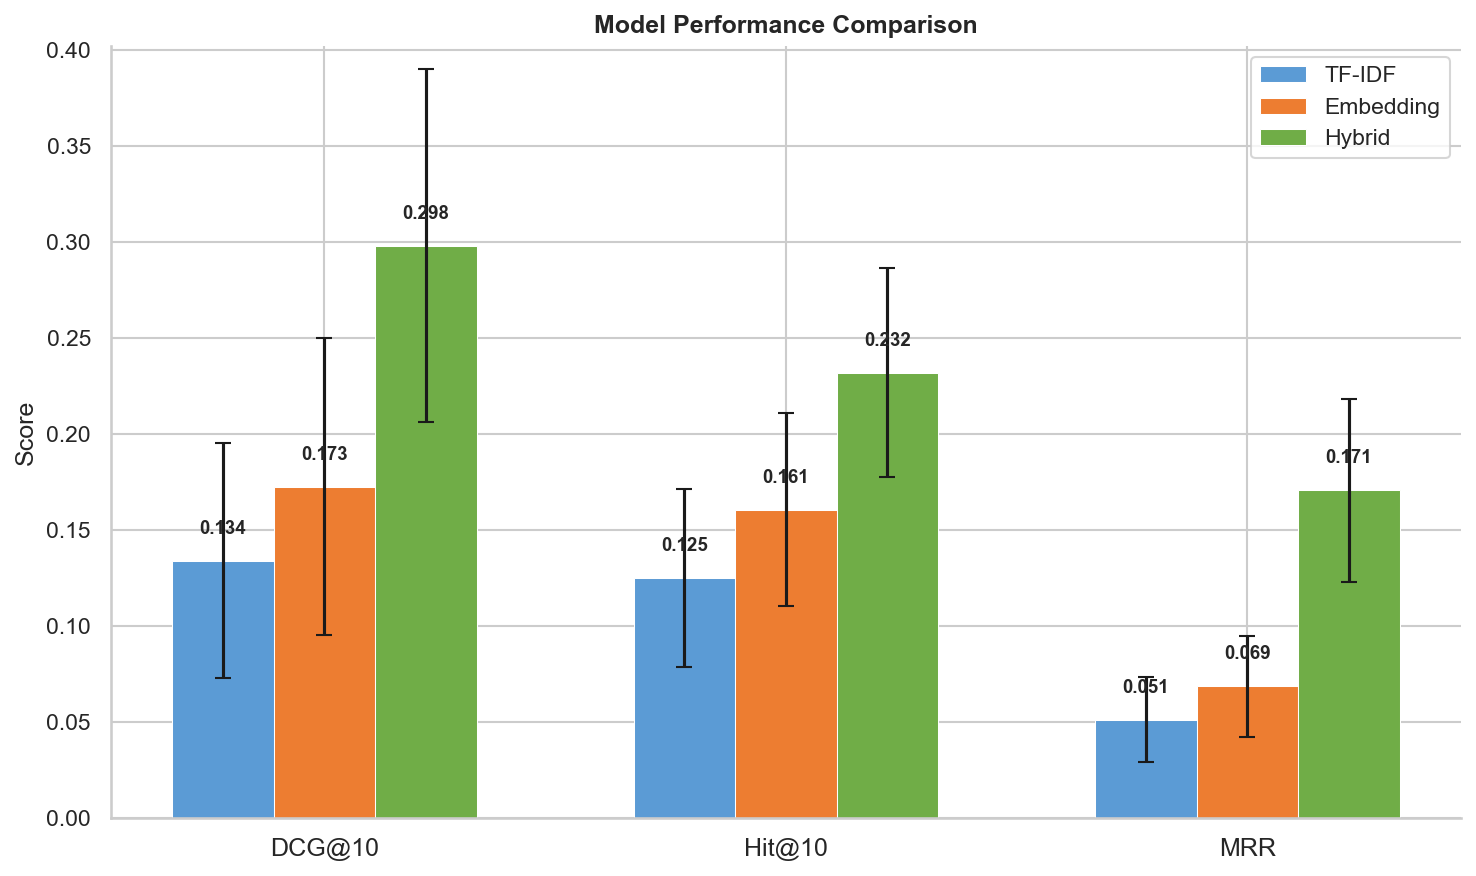

Saved: figures/model_comparison.png


In [3]:
metric_keys = ["DCG@10", "Hit@10", "MRR"]
se_keys = ["DCG@10_se", "Hit@10_se", "MRR_se"]

x = np.arange(len(metric_keys))
width = 0.22

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(MODEL_NAMES):
    vals = [metrics[model][k] for k in metric_keys]
    errs = [metrics[model][k] for k in se_keys]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=COLORS[model], yerr=errs, capsize=4,
                  edgecolor="white", linewidth=0.5)
    # Value labels
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(metric_keys, fontsize=12)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_ylim(0, max(metrics["Hybrid"][k] for k in metric_keys) * 1.35)
ax.legend(frameon=True, fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES / "model_comparison.png")
plt.show()
print("Saved: figures/model_comparison.png")

## 2. Per-Genre Performance Heatmap

Hit@10 broken down by primary genre for each model. Reveals which genres benefit most from embedding-based vs. lexical matching.

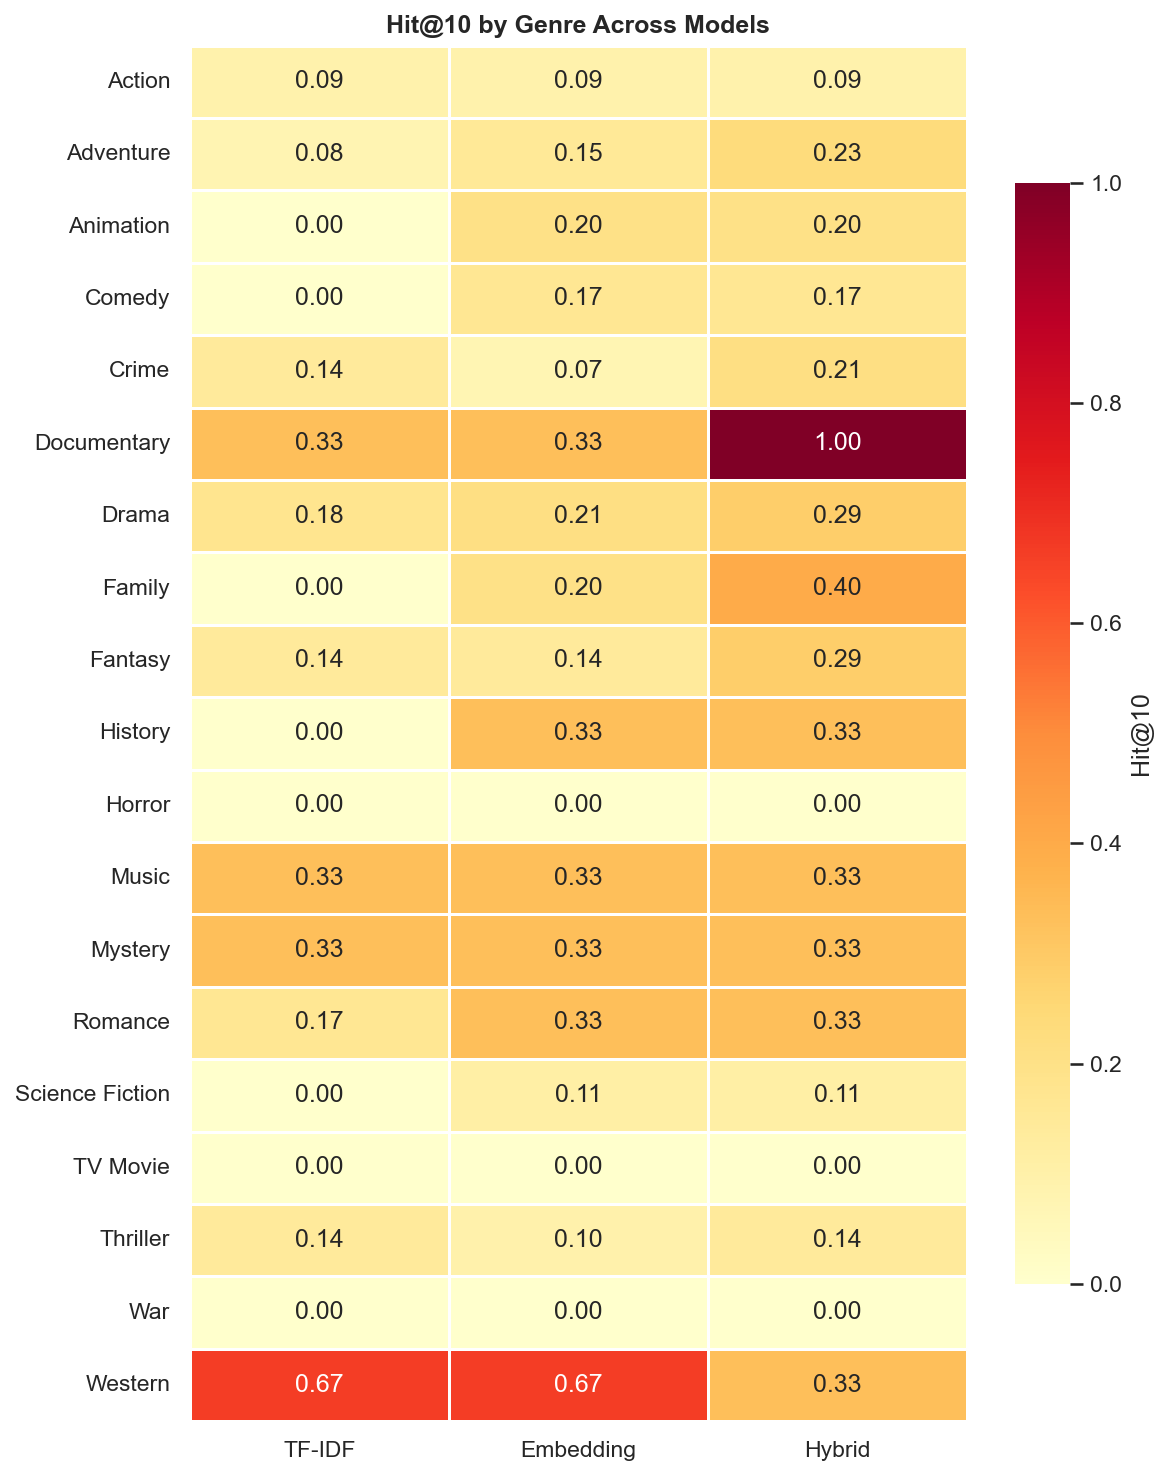

Saved: figures/genre_heatmap.png


In [4]:
# Build genre-model dataframe
genre_data = {}
for model in MODEL_NAMES:
    genre_data[model] = metrics[model]["per_genre_Hit@10"]

genre_df = pd.DataFrame(genre_data)
genre_df = genre_df.sort_index()

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(genre_df, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Hit@10", "shrink": 0.8},
            ax=ax, vmin=0, vmax=1)
ax.set_title("Hit@10 by Genre Across Models")
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
fig.savefig(FIGURES / "genre_heatmap.png")
plt.show()
print("Saved: figures/genre_heatmap.png")

## 3. Per-Relevance Analysis

Performance stratified by gold pair relevance level: **Remake** (direct adaptations, relevance=3), **Thematic** (shared themes, relevance=2), and **Genre** (same genre, relevance=1).

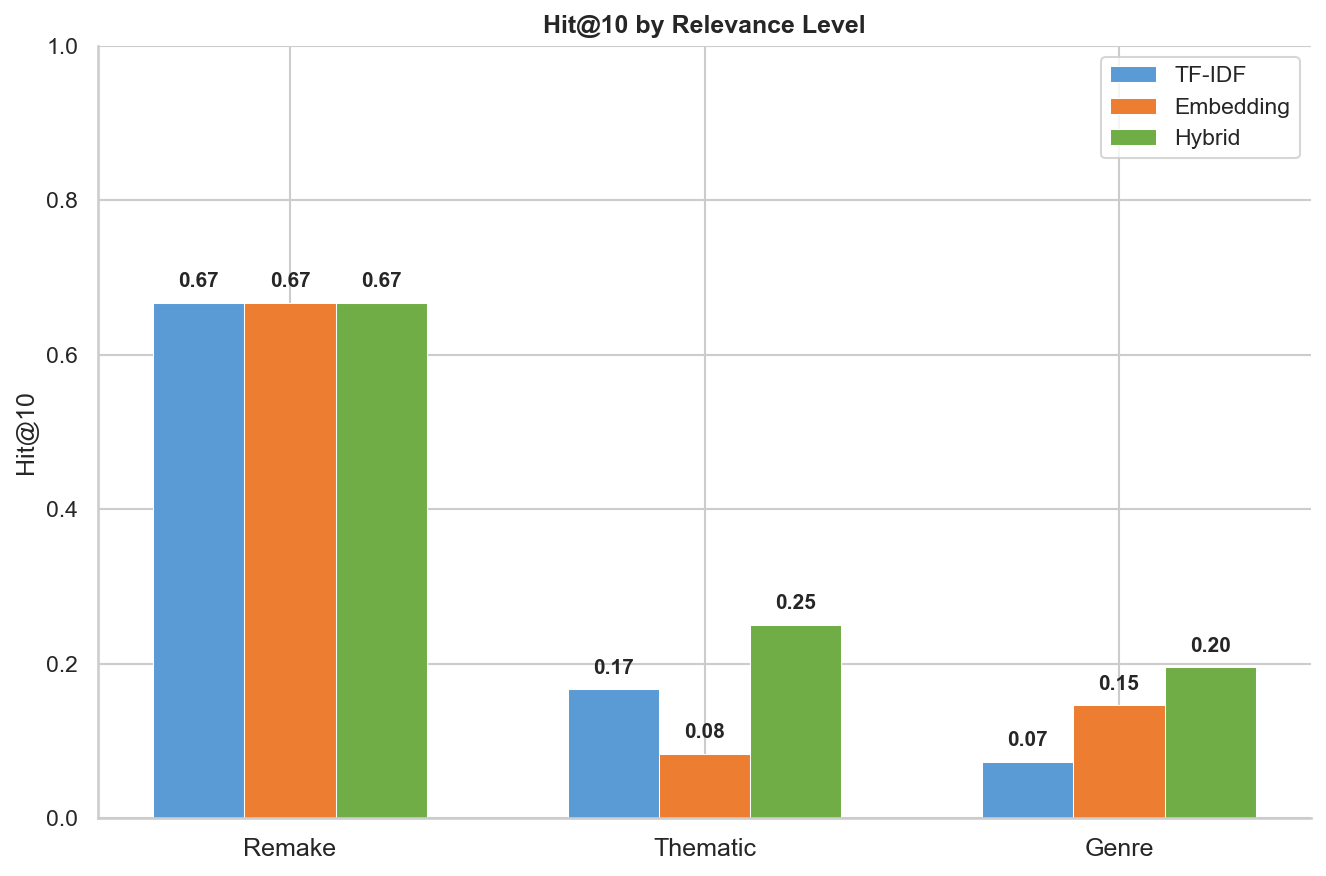

Saved: figures/relevance_analysis.png


In [5]:
rel_labels = ["Remake", "Thematic", "Genre"]
rel_keys = ["remake", "thematic", "genre"]

x = np.arange(len(rel_labels))
width = 0.22

fig, ax = plt.subplots(figsize=(9, 6))

for i, model in enumerate(MODEL_NAMES):
    vals = [metrics[model]["per_relevance_Hit@10"].get(k, 0) for k in rel_keys]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=COLORS[model], edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(rel_labels, fontsize=12)
ax.set_ylabel("Hit@10")
ax.set_title("Hit@10 by Relevance Level")
ax.set_ylim(0, 1.0)
ax.legend(frameon=True, fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES / "relevance_analysis.png")
plt.show()
print("Saved: figures/relevance_analysis.png")

## 4. Optimal Feature Weights

Grid search over 288 weight combinations. The hybrid model learns that **text similarity dominates**, genre provides useful signal, and cross-industry cast overlap contributes zero weight.

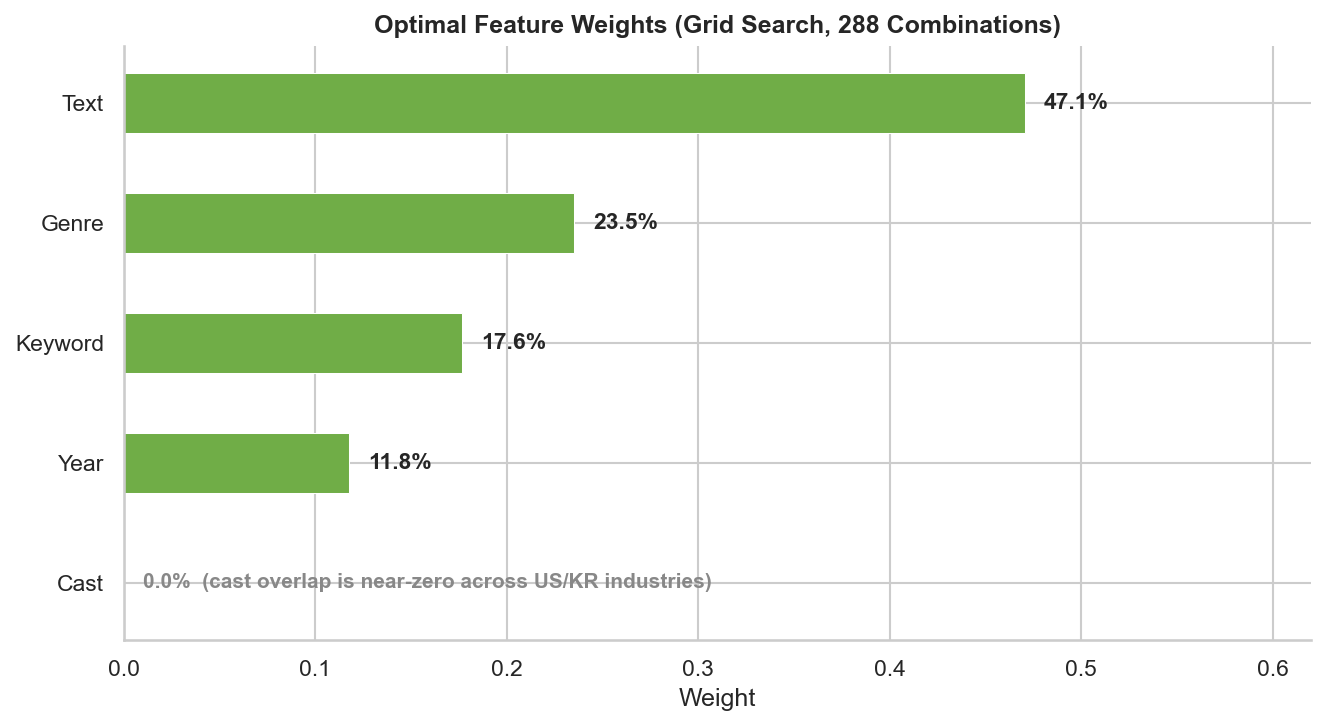

Saved: figures/feature_weights.png


In [6]:
weights = tune["best_weights"]
features = list(weights.keys())
values = [weights[f] for f in features]
feature_labels = [f.replace("_", " ").title() for f in features]

# Sort by weight descending
order = np.argsort(values)[::-1]
features_sorted = [feature_labels[i] for i in order]
values_sorted = [values[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(features_sorted, values_sorted,
               color=[COLORS["Hybrid"] if v > 0 else "#CCCCCC" for v in values_sorted],
               edgecolor="white", linewidth=0.5, height=0.5)

for bar, val in zip(bars, values_sorted):
    label = f"{val:.1%}"
    if val > 0:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                label, ha="left", va="center", fontsize=11, fontweight="bold")
    else:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{label}  (cast overlap is near-zero across US/KR industries)",
                ha="left", va="center", fontsize=10, fontweight="bold", color="#888888")

ax.set_xlabel("Weight")
ax.set_title("Optimal Feature Weights (Grid Search, 288 Combinations)")
ax.set_xlim(0, 0.62)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(FIGURES / "feature_weights.png")
plt.show()
print("Saved: figures/feature_weights.png")

## 5. Embedding Space Visualization (UMAP)

2D projection of sentence embeddings for both catalogs. US movies shown as circles, Korean movies as crosses, colored by dominant genre.

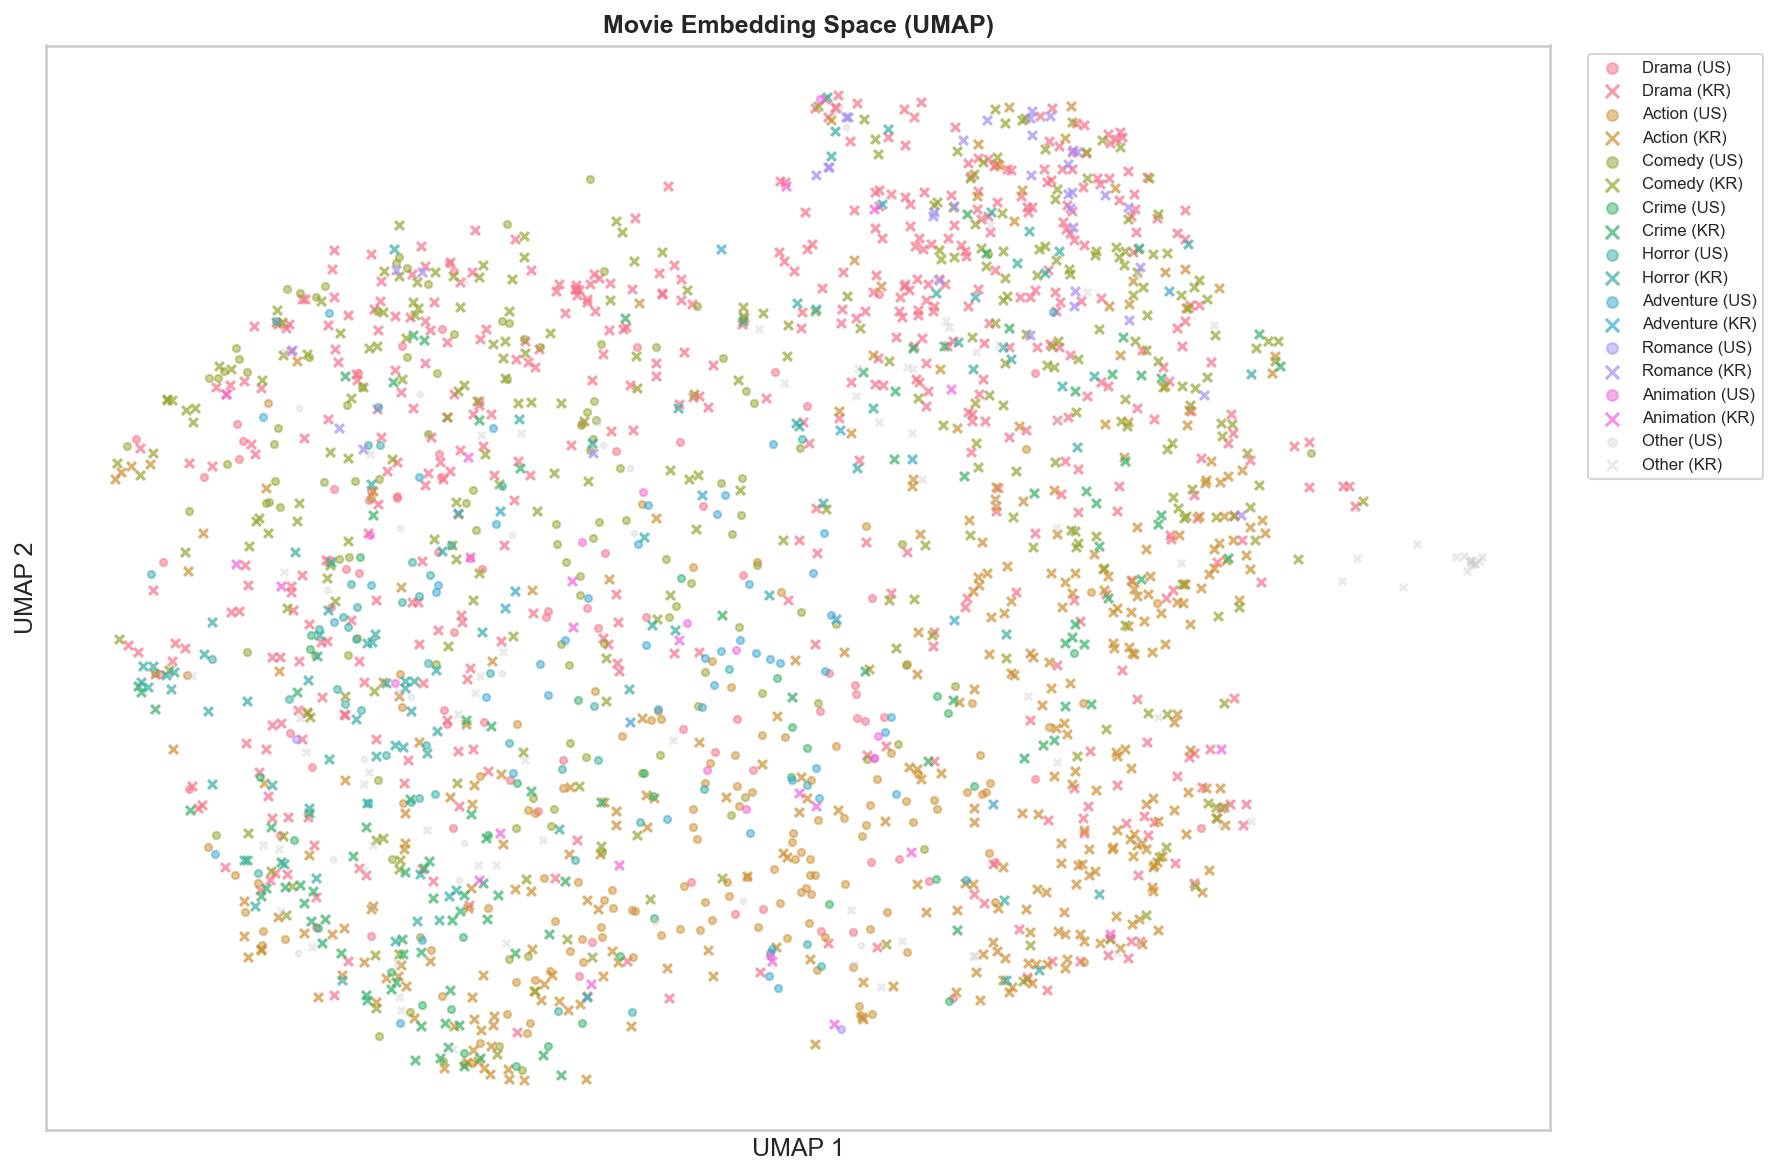

Saved: figures/embedding_umap.png


In [7]:
try:
    import umap

    # Load embeddings and genre info
    emb_us = np.load(DATA / "features" / "embeddings_us.npy")
    emb_kr = np.load(DATA / "features" / "embeddings_kr.npy")
    genres_us = np.load(DATA / "features" / "genres_us.npy")
    genres_kr = np.load(DATA / "features" / "genres_kr.npy")
    genre_vocab = joblib.load(DATA / "features" / "genre_vocab.joblib")

    # Sample US movies for tractability
    np.random.seed(42)
    us_idx = np.random.choice(len(emb_us), 500, replace=False)
    emb_us_sample = emb_us[us_idx]
    genres_us_sample = genres_us[us_idx]

    # Combine
    emb_all = np.vstack([emb_us_sample, emb_kr])
    genres_all = np.vstack([genres_us_sample, genres_kr])
    catalog_labels = ["US"] * len(emb_us_sample) + ["KR"] * len(emb_kr)

    # Dominant genre per movie
    dominant_genre_idx = genres_all.argmax(axis=1)
    dominant_genre = [genre_vocab[i] for i in dominant_genre_idx]

    # UMAP projection
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=1)
    proj = reducer.fit_transform(emb_all)

    # Select top genres for cleaner legend
    from collections import Counter
    genre_counts = Counter(dominant_genre)
    top_genres = [g for g, _ in genre_counts.most_common(8)]

    # Color map
    palette = sns.color_palette("husl", len(top_genres))
    genre_color = {g: palette[i] for i, g in enumerate(top_genres)}

    fig, ax = plt.subplots(figsize=(12, 8))
    n_us = len(emb_us_sample)

    for genre in top_genres:
        # US points
        mask_us = [i for i in range(n_us) if dominant_genre[i] == genre]
        if mask_us:
            ax.scatter(proj[mask_us, 0], proj[mask_us, 1],
                       c=[genre_color[genre]], marker="o", s=12, alpha=0.5, label=f"{genre} (US)")
        # KR points
        mask_kr = [i for i in range(n_us, len(proj)) if dominant_genre[i] == genre]
        if mask_kr:
            ax.scatter(proj[mask_kr, 0], proj[mask_kr, 1],
                       c=[genre_color[genre]], marker="x", s=18, alpha=0.7, label=f"{genre} (KR)")

    # Other genres (gray)
    mask_other_us = [i for i in range(n_us) if dominant_genre[i] not in top_genres]
    mask_other_kr = [i for i in range(n_us, len(proj)) if dominant_genre[i] not in top_genres]
    if mask_other_us:
        ax.scatter(proj[mask_other_us, 0], proj[mask_other_us, 1],
                   c="#CCCCCC", marker="o", s=8, alpha=0.3, label="Other (US)")
    if mask_other_kr:
        ax.scatter(proj[mask_other_kr, 0], proj[mask_other_kr, 1],
                   c="#CCCCCC", marker="x", s=12, alpha=0.4, label="Other (KR)")

    ax.set_title("Movie Embedding Space (UMAP)")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
              markerscale=1.5, frameon=True, ncol=1)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    fig.savefig(FIGURES / "embedding_umap.png")
    plt.show()
    print("Saved: figures/embedding_umap.png")

except ImportError:
    print("umap-learn not installed. Run `pip install umap-learn` to generate this plot.")
    print("Skipping UMAP visualization.")

## 6. Score Distributions for Example Queries

Embedding similarity (dot product) distributions for three well-known US movies against all 1,512 Korean movies. Gold pair matches are marked where they exist.

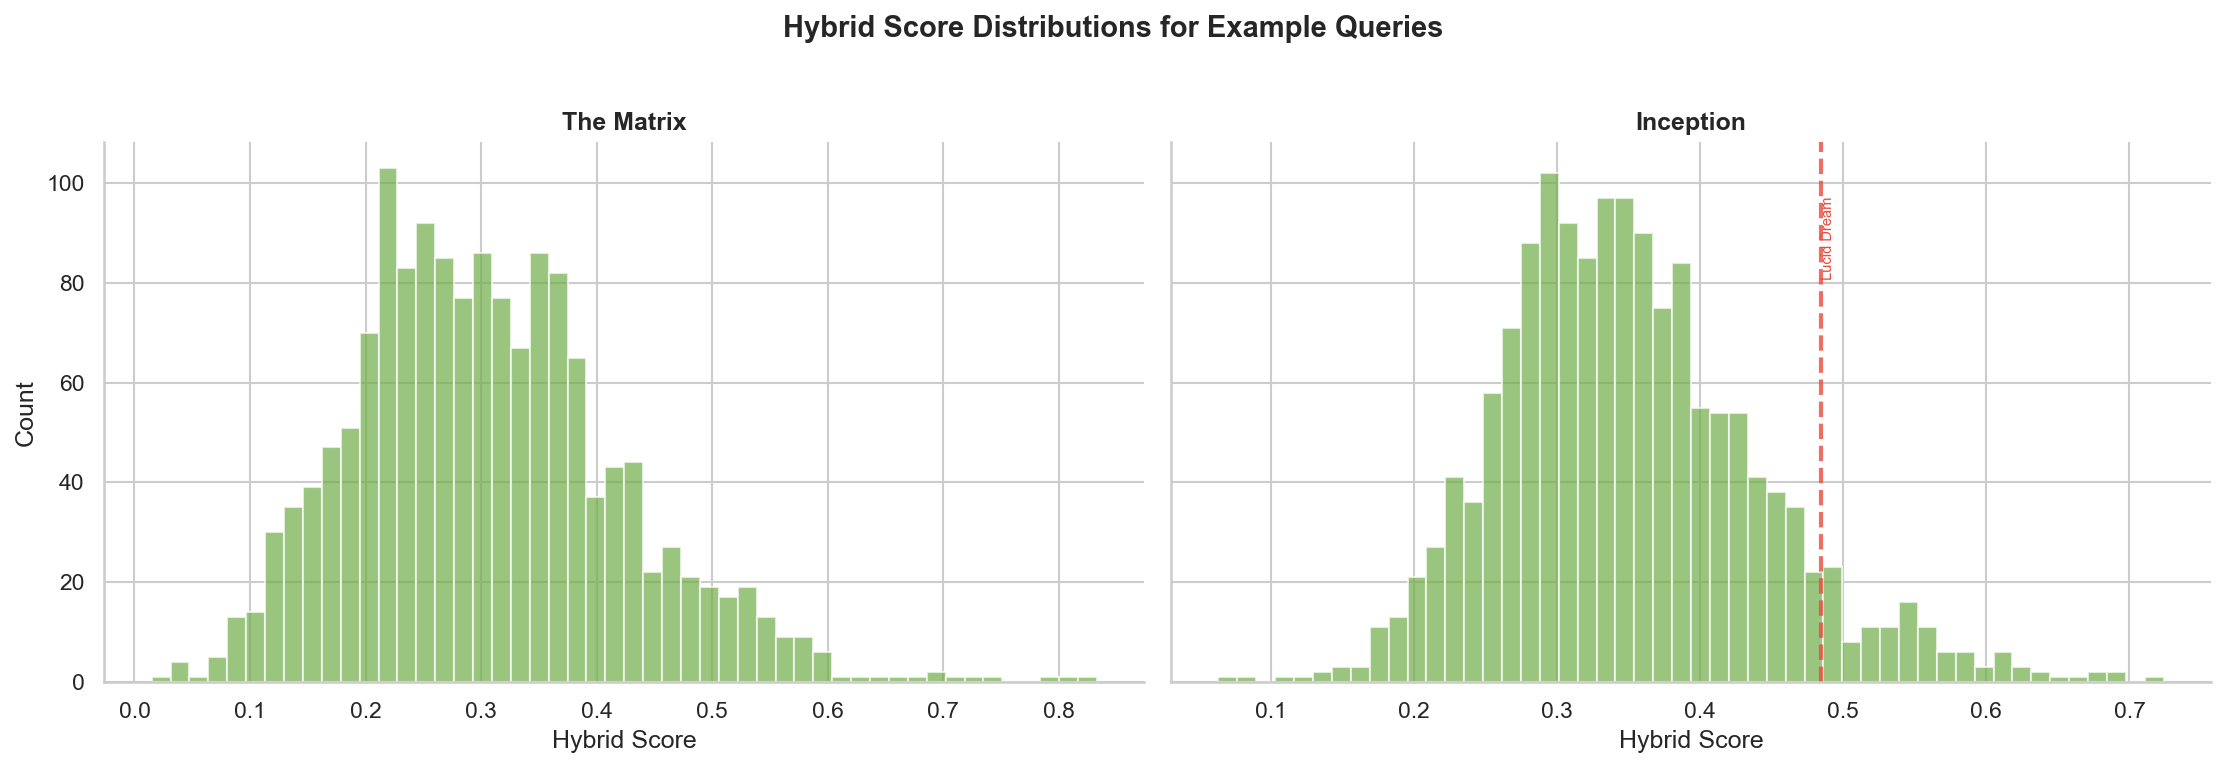

Saved: figures/score_distributions.png


In [8]:
import sys
sys.path.insert(0, "..")
from models import load_all_features, load_dataframes, _embedding_scores, _hybrid_scores

us_df, kr_df = load_dataframes()
features = load_all_features()

# Pick 3 well-known US movies
example_movies = ["Parasite", "The Matrix", "Inception"]
# Find indices (fallback to partial match)
example_indices = {}
for title in example_movies:
    mask = us_df["title"].str.contains(title, case=False, na=False)
    if mask.any():
        example_indices[title] = mask.idxmax()

fig, axes = plt.subplots(1, len(example_indices), figsize=(15, 5), sharey=True)

for ax, (title, idx) in zip(axes, example_indices.items()):
    scores = _hybrid_scores(idx, features)
    ax.hist(scores, bins=50, color=COLORS["Hybrid"], alpha=0.7, edgecolor="white")

    # Mark gold pairs if they exist
    gold_for_query = gold_pairs[gold_pairs["us_title"].str.contains(title, case=False, na=False)]
    if not gold_for_query.empty:
        for _, gp in gold_for_query.iterrows():
            kr_mask = kr_df["title"].str.contains(str(gp["kr_title"]), case=False, na=False)
            if kr_mask.any():
                kr_idx = kr_mask.idxmax()
                ax.axvline(scores[kr_idx], color="#E74C3C", linewidth=2, linestyle="--", alpha=0.8)
                ax.text(scores[kr_idx], ax.get_ylim()[1] * 0.9,
                        f" {gp['kr_title'][:20]}", fontsize=7, color="#E74C3C",
                        rotation=90, va="top")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Hybrid Score")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Count")
fig.suptitle("Hybrid Score Distributions for Example Queries", fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(FIGURES / "score_distributions.png")
plt.show()
print("Saved: figures/score_distributions.png")

## 7. Summary Statistics

Key numbers at a glance.

In [9]:
# Summary table
summary_rows = []
for model in MODEL_NAMES:
    m = metrics[model]
    summary_rows.append({
        "Model": model,
        "DCG@10": f"{m['DCG@10']:.3f} +/- {m['DCG@10_se']:.3f}",
        "Hit@10": f"{m['Hit@10']:.3f} +/- {m['Hit@10_se']:.3f}",
        "MRR": f"{m['MRR']:.3f} +/- {m['MRR_se']:.3f}",
        "nDCG@10": f"{m.get('nDCG@10', 0):.3f}",
        "P@5": f"{m.get('Precision@5', 0):.3f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
display(summary_df)

print(f"\nCatalog: {len(us_movies):,} US movies -> {len(kr_movies):,} Korean movies")
print(f"Evaluation: {len(gold_pairs)} gold pairs across {gold_pairs['us_title'].nunique()} queries")
print(f"Grid search: {tune.get('n_combos', '?')} weight combinations tested")
print(f"Best weights: {tune['best_weights']}")
print(f"Primary metric: DCG@10 = {metrics['Hybrid']['DCG@10']:.3f}")

,DCG@10,Hit@10,MRR,nDCG@10,P@5
Model,,,,,
TF-IDF,0.134 +/- 0.061,0.125 +/- 0.046,0.051 +/- 0.022,0.000,0.000
Embedding,0.173 +/- 0.077,0.161 +/- 0.050,0.069 +/- 0.026,0.000,0.000
Hybrid,0.298 +/- 0.092,0.232 +/- 0.054,0.171 +/- 0.048,0.000,0.000



Catalog: 5,000 US movies -> 1,512 Korean movies
Evaluation: 174 gold pairs across 58 queries
Grid search: 288 weight combinations tested
Best weights: {'text': 0.47058823529411764, 'genre': 0.23529411764705882, 'keyword': 0.1764705882352941, 'cast': 0.0, 'year': 0.11764705882352941}
Primary metric: DCG@10 = 0.298
